# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Print environment details
print("Current Working Directory:", os.getcwd())

# 2. Acquire and load your primary dataset
def load_esg_main_file(directory_path):
    file_list = os.listdir(directory_path)
    target_name = "ESGCSV.csv" if "ESGCSV.csv" in file_list else "ESGData.csv"
    data_frame = pd.read_csv(f"{directory_path}/{target_name}")
    return data_frame

target_relative_path = "../../../data/hw/hw_3/ESG_CSV"

df_primary_raw = load_esg_main_file(target_relative_path)
print(f"Total raw records loaded: {len(df_primary_raw)}")

Current Working Directory: /Users/ASUS/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
Total raw records loaded: 16969


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
df_esg_standard = df_primary_raw.rename(columns={"Country Code": "country_code", "Country Name": "country_name", "Indicator Code": "indicator_code"})
print(df_esg_standard.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16969 entries, 0 to 16968
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    16969 non-null  object 
 1   country_code    16969 non-null  object 
 2   Indicator Name  16969 non-null  object 
 3   indicator_code  16969 non-null  object 
 4   1960            1552 non-null   float64
 5   1961            2154 non-null   float64
 6   1962            2167 non-null   float64
 7   1963            2172 non-null   float64
 8   1964            2177 non-null   float64
 9   1965            2203 non-null   float64
 10  1966            2208 non-null   float64
 11  1967            2217 non-null   float64
 12  1968            2229 non-null   float64
 13  1969            2235 non-null   float64
 14  1970            3399 non-null   float64
 15  1971            3638 non-null   float64
 16  1972            3638 non-null   float64
 17  1973            3637 non-null  

In [3]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
df_co2_all = df_esg_standard.query("indicator_code == 'EN.ATM.CO2E.PC'")

df_primary_subset = pd.DataFrame({
    "country_code": df_co2_all["country_code"],
    "country_name": df_co2_all["country_name"],
    "co2_emissions": df_co2_all["2020"]
})
print(df_primary_subset.head())

    country_code                    country_name  co2_emissions
10           ARB                      Arab World       3.890153
81           CSS          Caribbean small states       6.041616
152          CEB  Central Europe and the Baltics       5.913012
223          EAR      Early-demographic dividend       2.003989
294          EAS             East Asia & Pacific       6.207435


In [4]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
df_filtered_countries = df_primary_subset.query("~country_code.str.contains('WLD|IBD|IBT|LMC|HIC|MIC|EAS|ECS|LCN|MEA|NAC|SAS|SSF')").copy()
print(f"Observations after filtering regional aggregates: {len(df_filtered_countries)}")


Observations after filtering regional aggregates: 226


In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
df_clean_primary = df_filtered_countries.dropna(subset=["co2_emissions"]).copy()
print(f"Final valid primary observations: {len(df_clean_primary)}")

Final valid primary observations: 224


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
df_gdp_all = df_esg_standard.query("indicator_code == 'NY.GDP.MKTP.KD.ZG'")

df_secondary_subset = pd.DataFrame({
    "country_code": df_gdp_all["country_code"],
    "gdp_growth": df_gdp_all["2020"]
})
df_clean_secondary = df_secondary_subset.dropna(subset=["gdp_growth"]).copy()
print(f"Valid secondary rows: {len(df_clean_secondary)}")

Valid secondary rows: 233


In [7]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
df_merged_policy = pd.merge(df_clean_primary, df_clean_secondary, on="country_code", how="inner")
df_merged_policy = df_merged_policy.dropna(subset=["co2_emissions", "gdp_growth"]).copy()

print("Final Merged Dataset Shape:", df_merged_policy.shape)
print(df_merged_policy.head())

Final Merged Dataset Shape: (218, 4)
  country_code                                 country_name  co2_emissions  \
0          ARB                                   Arab World       3.890153   
1          CSS                       Caribbean small states       6.041616   
2          CEB               Central Europe and the Baltics       5.913012   
3          EAR                   Early-demographic dividend       2.003989   
4          EAP  East Asia & Pacific (excluding high income)       5.966700   

   gdp_growth  
0   -4.757145  
1   -9.113253  
2   -3.315368  
3   -4.215304  
4    1.345289  


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
df_merged_policy["growth_group"] = pd.qcut(df_merged_policy["gdp_growth"], q=3, labels=["Low Growth", "Medium Growth", "High Growth"])

df_policy_summary = df_merged_policy.groupby("growth_group", observed=False).agg(
    avg_co2_emissions=("co2_emissions", "mean"),
    median_gdp_growth=("gdp_growth", "median"),
    country_count=("country_code", "count")
).reset_index()

print(df_policy_summary)

    growth_group  avg_co2_emissions  median_gdp_growth  country_count
0     Low Growth           3.523139          -8.868221             73
1  Medium Growth           4.970694          -3.376704             72
2    High Growth           2.856440           0.503032             73


- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

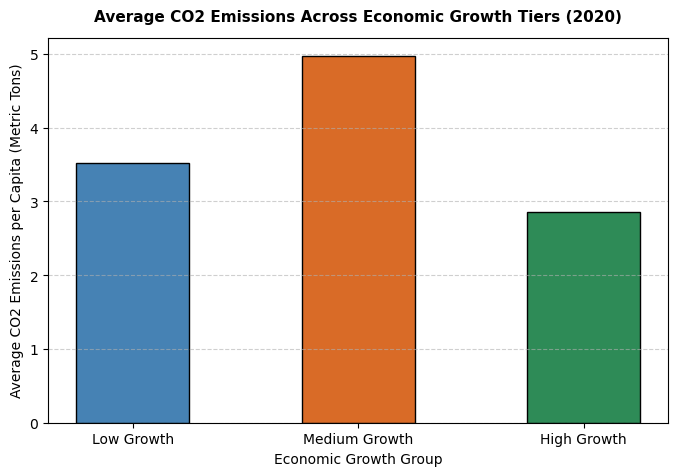

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
plt.figure(figsize=(8, 5))
plt.bar(df_policy_summary["growth_group"], df_policy_summary["avg_co2_emissions"], color=["#4682B4", "#D96B27", "#2E8B57"], edgecolor="black", width=0.5)
plt.title("Average CO2 Emissions Across Economic Growth Tiers (2020)", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Economic Growth Group", fontsize=10)
plt.ylabel("Average CO2 Emissions per Capita (Metric Tons)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

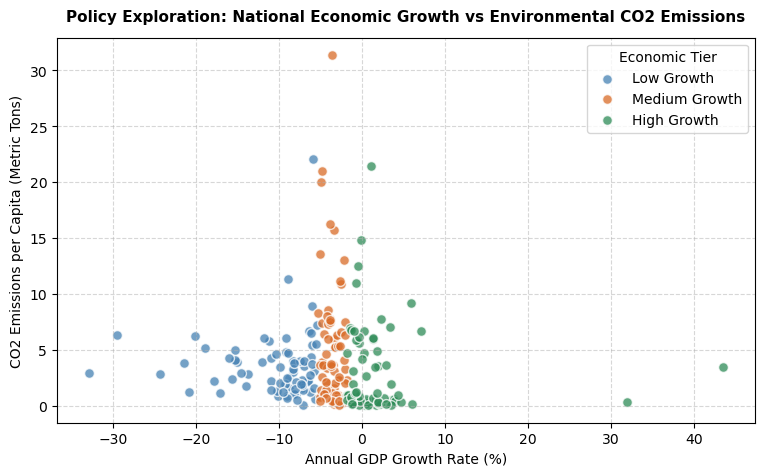

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
plt.figure(figsize=(9, 5))
colors_map = {"Low Growth": "#4682B4", "Medium Growth": "#D96B27", "High Growth": "#2E8B57"}
for group_name, sub_df in df_merged_policy.groupby("growth_group", observed=False):
    plt.scatter(sub_df["gdp_growth"], sub_df["co2_emissions"], label=group_name, color=colors_map[group_name], alpha=0.75, edgecolors="white", s=50)
plt.title("Policy Exploration: National Economic Growth vs Environmental CO2 Emissions", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Annual GDP Growth Rate (%)", fontsize=10)
plt.ylabel("CO2 Emissions per Capita (Metric Tons)", fontsize=10)
plt.legend(title="Economic Tier")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

                            OLS Regression Results                            
Dep. Variable:          co2_emissions   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4833
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.488
Time:                        02:40:16   Log-Likelihood:                -631.85
No. Observations:                 218   AIC:                             1268.
Df Residuals:                     216   BIC:                             1274.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6588      0.344     10.624      0.0

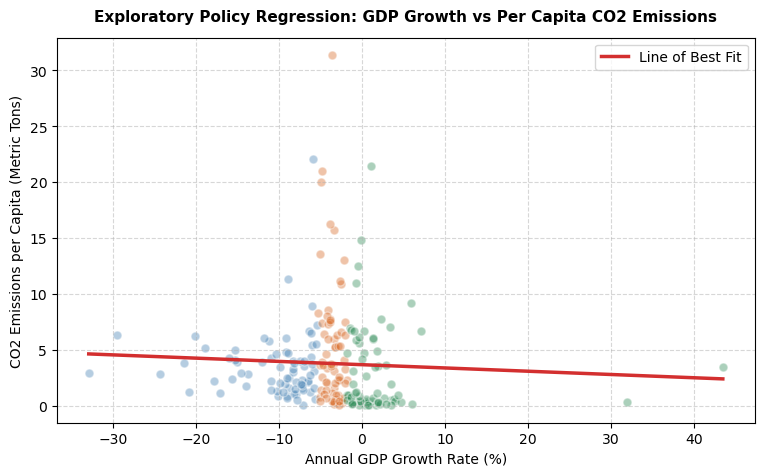

In [11]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import numpy as np
import statsmodels.api as sm

x_data = df_merged_policy["gdp_growth"]
y_data = df_merged_policy["co2_emissions"]
x_constant = sm.add_constant(x_data)
regression_results = sm.OLS(y_data, x_constant).fit()

print(regression_results.summary())

plt.figure(figsize=(9, 5))
for group_name, sub_df in df_merged_policy.groupby("growth_group", observed=False):
    plt.scatter(sub_df["gdp_growth"], sub_df["co2_emissions"], color=colors_map[group_name], alpha=0.4, edgecolors="white", s=40)
x_line = np.linspace(x_data.min(), x_data.max(), 100)
y_line = regression_results.params.iloc[0] + regression_results.params.iloc[1] * x_line
plt.plot(x_line, y_line, color="#D32F2F", linestyle="-", linewidth=2.5, label="Line of Best Fit")
plt.title("Exploratory Policy Regression: GDP Growth vs Per Capita CO2 Emissions", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Annual GDP Growth Rate (%)", fontsize=10)
plt.ylabel("CO2 Emissions per Capita (Metric Tons)", fontsize=10)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.